In [281]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

/home/nichettg/Ubuntu/Laboratorio/funzioni.py:235: SyntaxWarning: invalid escape sequence '\p'
  latex_file.write('\t' + '\t' +f"Equazione della retta & $y=({form(b)}\pm{form(sb)})x+({form(a)}\pm{form(sa)})$" + r"\\" + '\n')
/home/nichettg/Ubuntu/Laboratorio/funzioni.py:235: SyntaxWarning: invalid escape sequence '\p'
  latex_file.write('\t' + '\t' +f"Equazione della retta & $y=({form(b)}\pm{form(sb)})x+({form(a)}\pm{form(sa)})$" + r"\\" + '\n')
/home/nichettg/Ubuntu/Laboratorio/funzioni.py:236: SyntaxWarning: invalid escape sequence '\p'
  latex_file.write('\t' +'\t' +f"Indice Pearson & ${form(pearson_xy)}\pm{form(s_pearson_xy)}$" + r"\\" + '\n')


In [296]:
#Correzione distanza oggetto
ogg = 74.0
#Lunghezza per Bessel sìcon correzione
lunghezza = 561 + ogg

# 1. Punti Coniugati


### 1.1 Lettura

In [283]:
def nome (stringa):
    """
    Estrae il nome dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace(f'./Data/dati_','').replace('.csv','')
    return stringa_nuova

In [284]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir(f'./Data'))]
data = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data[nome(input_file)] = {
        "immagine": letti["immagine"],
        "lente": letti["lente"],
    }

### 1.2 Analisi

$$
Y = \frac{1}{f} - X
$$

$$
\frac{1}{x_{lente}} = \frac{1}{f} - \frac{1}{x_{immagine}}
$$

Le incertezze usate sono state stimate come risoluzione (0.5mm) fratto il quadrato della misura: questo è dovuto alla propagazione delle incertezze per il reciproco di un valore.

In [285]:
distanze = {}
for colore,dati in data.items():
    p = np.array(dati["lente"]) + ogg
    q = np.array(dati["immagine"]) - np.array(dati["lente"])

    anal = f.elaborato(1/q, 1/p, 0.5/(p*p), "test.txt", 0, vsx = 0.5/(q*q), ritorno = True)

    print(f"f = {1/anal[0]} mm")
    distanze[colore] = {
        "p" : p,
        "q" : q,
        "f" : 1/anal[0],
        "sf" : anal[2]/anal[0]**2
    }
    print(f"p-value = {anal[5]}")


Elaborazione serie 1
	Incertezze x variabili
	Incertezze y variabili
	Minimi quadrati 3
f = 147.8182650929017 mm
p-value = 5.556578070447376e-65

Elaborazione serie 1
	Incertezze x variabili
	Incertezze y variabili
	Minimi quadrati 3
f = 143.15349405854724 mm
p-value = 5.3301163127085456e-58


### 1.3 Grafici

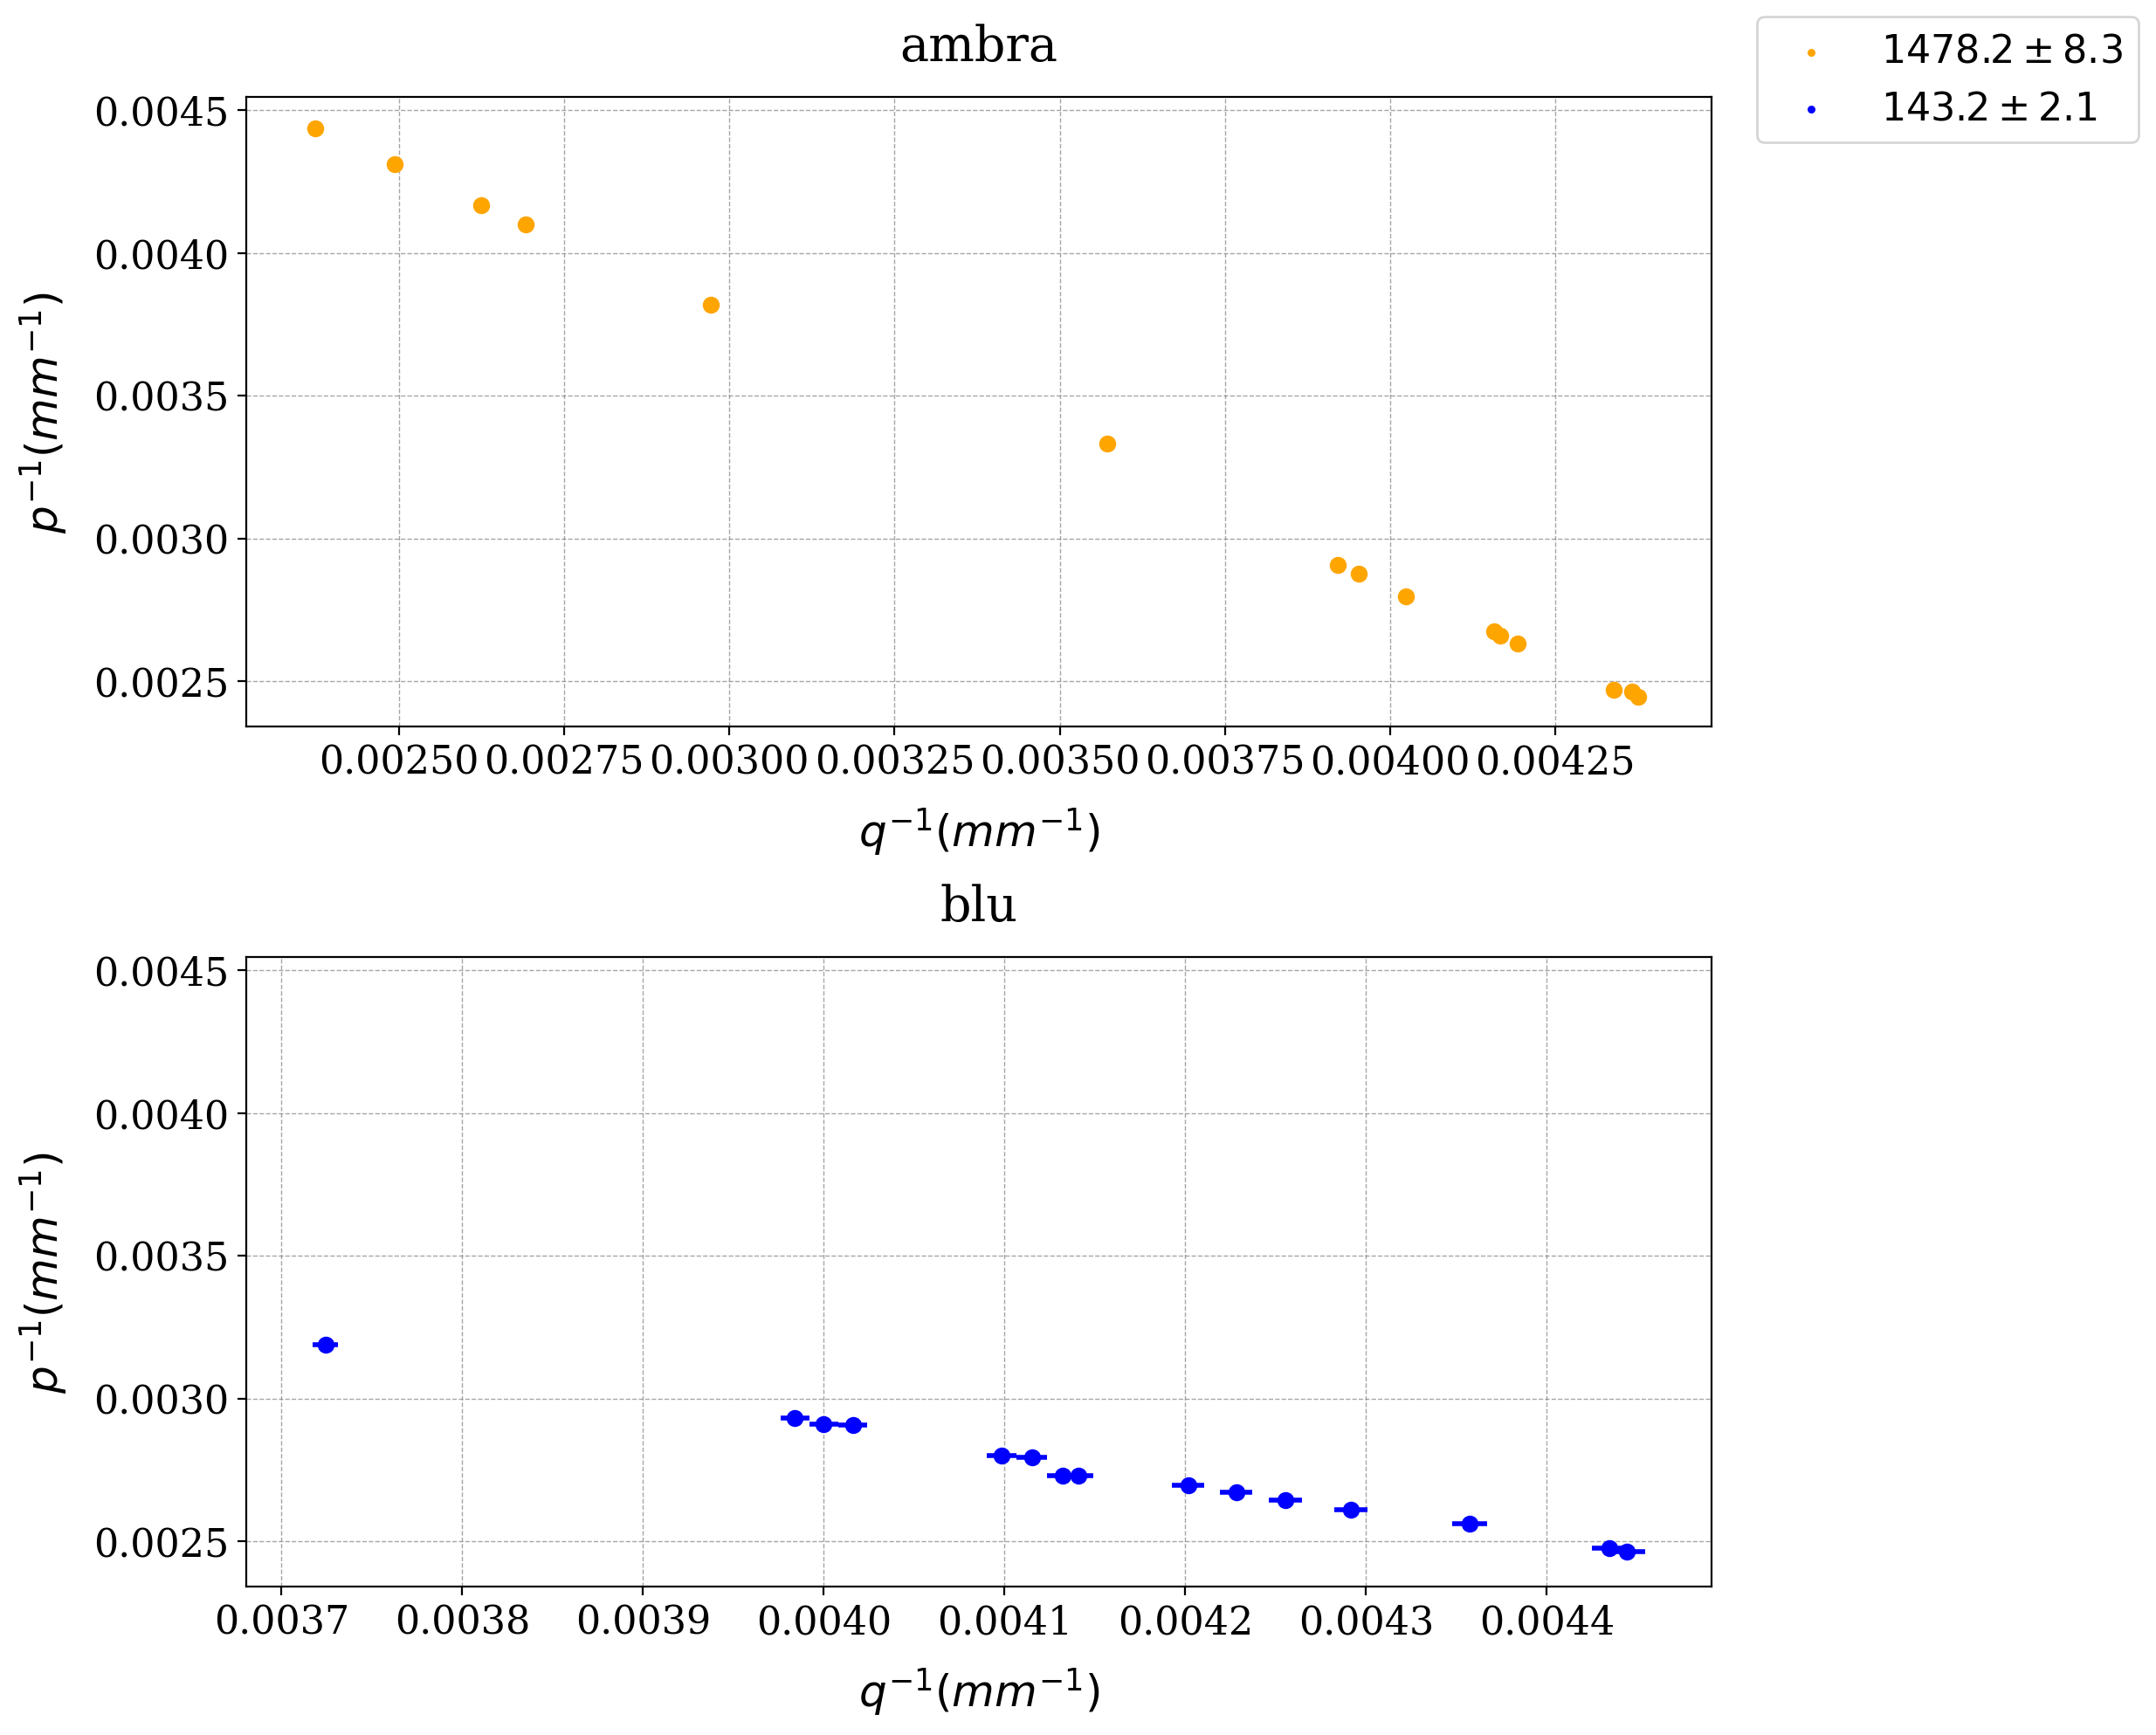

In [286]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharey=True)

ax = axes

titolo = "Test"
colore = next(color_cycle)

for i, (input_file, distanza) in enumerate(zip(input_files, distanze.values())):

    ax = axes[i]

    titolo = nome(input_file)
    if i == 0 : colore = "orange"
    elif i == 1 : colore = "blue"

    p = distanza["p"]
    q = distanza["q"]

    ax.errorbar(1/q, 1/p, xerr = 0.5/(q*q) , yerr = 0.5/(p*p), color=colore, fmt = 'o')
    #meme.scrivi(ax,"CHE SCHIFO", densita=1000)
    #gf.numera_punti(ax,q,p)

    stringa_f = gf.formatta_errore(distanza["f"],distanza["sf"])

    gf.parametri_grafico(ax, titolo, "$q^{-1}(mm^{-1})$", "$p^{-1}(mm^{-1})$")
    gf.descrizione_legenda(ax, stringa_f, color=colore)
gf.salva_grafico(fig, "grafici.pdf")

# 2. Bessel

### 2.1 Lettura

In [287]:
input_files = [f"./Bessel/{nome_file}" for nome_file in sorted(os.listdir(f'./Bessel'))]
data_bessel = {}
nome = ["ambra","blu"]

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data_bessel[nome[i]] = {
        "pl+": letti["pl+"],
        "pl-": letti["pl-"],
    }

### 2.2 Analisi

In [ ]:
f_bessel = {}

for i,dati in enumerate(data_bessel.values()):
    pl_piu = np.mean(np.array(dati["pl+"]))
    pl_meno = np.mean(np.array(dati["pl-"]))
    s_pl_piu = f.s_media(dati["pl+"])
    s_pl_meno = f.s_media(dati["pl-"])
    ritorno = f.propaga_incertezza("(L**2 - (pl_piu - pl_meno)**2) / (4 * L)", ["L","pl_piu","pl_meno"],
                     valori = [lunghezza, pl_piu, pl_meno],
                     incertezze = [0.5/np.sqrt(12), s_pl_piu, s_pl_meno],
                     ritorno = True)
    f_bessel[nome[i]] = {
        "f" : (L**2 - (pl_piu - pl_meno)**2) / (4 * L),
        "sf" : ritorno[0],
        }

In [295]:
gf.display_dizionario(distanze)

In [294]:
gf.display_dizionario(f_bessel)